[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ssindiUCM/SIAM-LS26-MT1/blob/main/ML_Example1_Classification.ipynb)

# Machine Learning for Biological Modeling
## SIAM Life Sciences 2026 Mini-Tutorial: Machine Learning Section
### Example 1: Binary Classification

We build and evaluate classifiers for binary biological outcomes (e.g., disease vs. healthy, malignant vs. benign).

Working through this example, you will:
- fit logistic regression models with different feature sets and compare performance;
- use cross-validation to get robust performance estimates;
- apply AIC/BIC for principled model selection.

## 1. Setup

In [46]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import ranksums
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, roc_curve, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 12

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")


---

## 2. Synthetic Classification Dataset

We generate a synthetic dataset where we *know* the ground truth — which features carry real signal and which are noise. This lets us check whether our modeling pipeline recovers the right answer before applying it to real data.

The dataset has **1,000 samples**, **5 features**, and a **binary outcome**. Only `Feature_1` and `Feature_2` are informative; the remaining three are pure noise.

In [47]:
X, y = make_classification(
    n_samples=1000,     # total number of observations (rows)
    n_features=5,       # total number of predictor variables (columns)
    n_informative=2,    # features that contain true signal used to separate classes
    n_redundant=0,      # linear combinations of informative features (correlated features)
    n_classes=2,        # number of outcome classes (binary classification)
    weights=[0.7, 0.3], # class proportions: 70% Class 0, 30% Class 1
    hypercube=True,     # place class clusters on vertices of a hypercube (default structure)
    class_sep=2,        # how far apart are the classes
    shift=0.0,          # value added to all features (0 = no shift)
    scale=1.0,          # multiply all features by this value (1 = no scaling)
    shuffle=False,      # randomly shuffle features so informative ones are not grouped together (if false, features ordered as: informative, redundant, repeated, random)
    random_state=RANDOM_STATE, # seed for reproducibility; same data generated every run
) 

feature_names = [f"Feature_{i+1}" for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name="Class")

print("Class counts:")
display(y_series.value_counts().rename_axis("Class").to_frame("Count"))

display(X_df.head())

Class counts:


,Count
Class,
0,700
1,300


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
0,-1.682996,-1.450427,0.239514,1.957922,-1.494348
1,-1.949407,-1.170737,-1.233590,-0.948959,-0.352307
2,-1.532461,-0.942712,-0.386120,0.131254,1.736490
3,-2.005906,-1.948323,1.281945,-0.589927,0.776426
4,-2.399340,-3.630167,0.314326,-0.285425,1.011604


---

## 3. Feature Comparison by Class

A univariate check (Wilcoxon rank-sum test + boxplots) shows which features differ between classes. This is a first look, not a substitute for model validation.

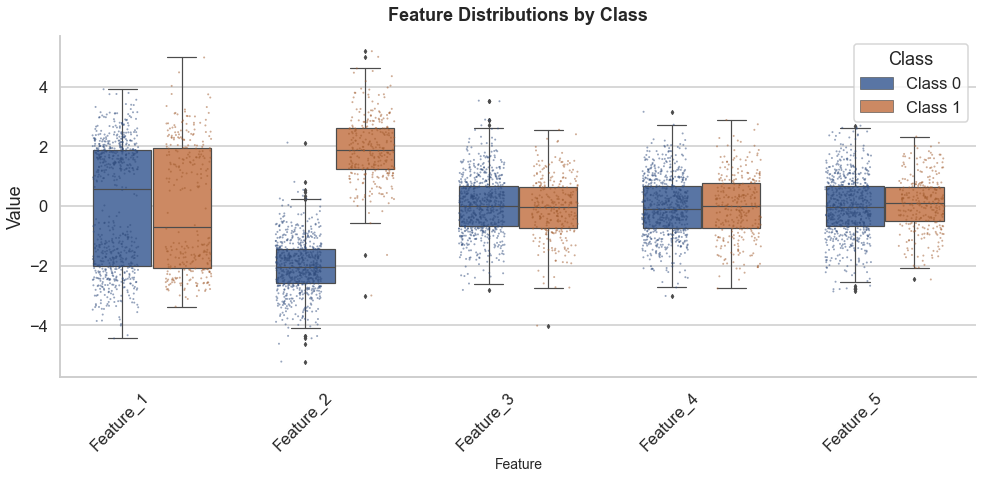

In [48]:
# -----------------------------
# Compute rank-sum statistics
# -----------------------------
rank_results = []

for col in X_df.columns:
    class_0 = X_df.loc[y_series == 0, col]
    class_1 = X_df.loc[y_series == 1, col]
    p_value = ranksums(class_0, class_1).pvalue
    mean_difference = class_1.mean() - class_0.mean()

    rank_results.append({
        "Feature": col,
        "Mean difference (Class 1 - Class 0)": mean_difference,
        "Wilcoxon rank-sum p-value": p_value,
    })

rank_results_df = pd.DataFrame(rank_results)

# Order features by p-value
ordered_features = rank_results_df #.sort_values( by="Wilcoxon rank-sum p-value")["Feature"].tolist()
ordered_features = rank_results_df["Feature"].tolist()


# -----------------------------
# Prepare plotting dataframe
# -----------------------------
plot_df = X_df.copy()
plot_df["Class"] = y_series.values
long_df = plot_df.melt(id_vars="Class", var_name="Feature", value_name="Value")

# -----------------------------
# Pretty plot
# -----------------------------
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=long_df,
    x="Feature",
    y="Value",
    hue="Class",
    order=ordered_features,
    palette=["#4C72B0", "#DD8452"],
    width=0.65,
    linewidth=1.2,
    fliersize=3
)

sns.stripplot(
    data=long_df,
    x="Feature",
    y="Value",
    hue="Class",
    order=ordered_features,
    dodge=True,
    palette=["#2F4B7C", "#A05A2C"],
    alpha=0.5,
    size=2,
    jitter=0.25
)

ax.set_title("Feature Distributions by Class", fontsize=18, weight="bold", pad=15)
ax.set_xlabel("Feature", fontsize=14)
# ax.set_ylabel("Value", fontsize=14)

plt.xticks(rotation=45, ha="right")

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], ["Class 0", "Class 1"], title="Class", loc="upper right", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

---

## 4. Logistic Regression

We fit logistic regression models using all combinations of 1–5 features and compare test-set ROC AUC. The model is trained on 80% of the data (stratified split) and evaluated on the held-out 20%.

Features are standardized using training-set statistics only — applying the same scaling to the test set avoids data leakage.

In [49]:
results = []
roc_data = {}
feature_list = X_df.columns.tolist()

for n_features in [1, 2, 3,4,5]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_df[list(feature_combo)]

        X_train, X_test, y_train, y_test = train_test_split(
            X_subset,
            y_series,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=y_series,
        )

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000),
        )

        model.fit(X_train, y_train)

        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        train_auc = roc_auc_score(y_train, y_train_prob)
        test_auc = roc_auc_score(y_test, y_test_prob)
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)

        results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Training ROC AUC": train_auc,
            "Testing ROC AUC": test_auc,
        })

        roc_data[feature_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": test_auc,
        }

single_split_results_df = pd.DataFrame(results).sort_values(
    by="Testing ROC AUC",
    ascending=False,
)

display(single_split_results_df.head(10).round(3))

top_single_split_models = single_split_results_df.head(5)

## ROC plots for top 10
# plt.figure(figsize=(9, 7))
# colors = plt.cm.tab10(np.linspace(0, 1, len(top_single_split_models)))

# for color, (_, row) in zip(colors, top_single_split_models.iterrows()):
#     label = row["Features"]
#     plt.plot(
#         roc_data[label]["fpr"],
#         roc_data[label]["tpr"],
#         color=color,
#         linewidth=2.5,
#         label=f"{label} (AUC = {roc_data[label]['auc']:.2f})",
#     )

# plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Top Logistic Regression Models: Single Train/Test Split")
# plt.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


,Num Features,Features,Training ROC AUC,Testing ROC AUC
30,5,Feature_1 + Feature_2 + Feature_3 + Feature_4 + Feature_5,0.994,1.0
29,4,Feature_2 + Feature_3 + Feature_4 + Feature_5,0.993,1.0
27,4,Feature_1 + Feature_2 + Feature_4 + Feature_5,0.994,1.0
26,4,Feature_1 + Feature_2 + Feature_3 + Feature_5,0.994,1.0
5,2,Feature_1 + Feature_2,0.994,1.0
23,3,Feature_2 + Feature_4 + Feature_5,0.993,1.0
22,3,Feature_2 + Feature_3 + Feature_5,0.993,1.0
17,3,Feature_1 + Feature_2 + Feature_5,0.994,1.0
16,3,Feature_1 + Feature_2 + Feature_4,0.994,1.0
11,2,Feature_2 + Feature_5,0.993,1.0


---

## 5. Cross-Validation for Feature Selection

Cross-validation gives a more stable performance estimate by repeatedly training and testing on different folds of the same data. We use stratified folds to preserve class balance across splits.

In [50]:
cv_results = []
cv_roc_data = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for n_features in [1, 2, 3,4,5]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_df[list(feature_combo)]

        fold_aucs = []
        fold_rocs = []

        for train_idx, test_idx in cv.split(X_subset, y_series):
            X_train = X_subset.iloc[train_idx]
            X_test = X_subset.iloc[test_idx]
            y_train = y_series.iloc[train_idx]
            y_test = y_series.iloc[test_idx]

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000),
            )

            model.fit(X_train, y_train)
            y_prob = model.predict_proba(X_test)[:, 1]

            auc = roc_auc_score(y_test, y_prob)
            fpr, tpr, _ = roc_curve(y_test, y_prob)

            fold_aucs.append(auc)
            fold_rocs.append((fpr, tpr))

        cv_results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Mean CV ROC AUC": np.mean(fold_aucs),
            "Std CV ROC AUC": np.std(fold_aucs),
        })

        cv_roc_data[feature_name] = {
            "fold_rocs": fold_rocs,
            "mean_auc": np.mean(fold_aucs),
        }

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV ROC AUC",
    ascending=False,
)

display(cv_results_df.head(10).round(3))


## ROC curves
# top_cv_models = cv_results_df.head(5)

# plt.figure(figsize=(10, 8))
# colors = plt.cm.tab10(np.linspace(0, 1, len(top_cv_models)))

# for color, (_, row) in zip(colors, top_cv_models.iterrows()):
#     label = row["Features"]
#     for fpr, tpr in cv_roc_data[label]["fold_rocs"]:
#         plt.plot(fpr, tpr, color=color, linewidth=2, alpha=0.55)

#     plt.plot(
#         [],
#         [],
#         color=color,
#         linewidth=2.5,
#         label=f"{label} (mean AUC = {cv_roc_data[label]['mean_auc']:.2f})",
#     )

# plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Top Logistic Regression Models: 5-Fold Cross-Validation")
# plt.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


,Num Features,Features,Mean CV ROC AUC,Std CV ROC AUC
17,3,Feature_1 + Feature_2 + Feature_5,0.995,0.004
26,4,Feature_1 + Feature_2 + Feature_3 + Feature_5,0.995,0.004
27,4,Feature_1 + Feature_2 + Feature_4 + Feature_5,0.995,0.005
5,2,Feature_1 + Feature_2,0.995,0.004
16,3,Feature_1 + Feature_2 + Feature_4,0.995,0.004
30,5,Feature_1 + Feature_2 + Feature_3 + Feature_4 + Feature_5,0.995,0.004
15,3,Feature_1 + Feature_2 + Feature_3,0.995,0.004
25,4,Feature_1 + Feature_2 + Feature_3 + Feature_4,0.995,0.004
1,1,Feature_2,0.994,0.005
11,2,Feature_2 + Feature_5,0.994,0.005


---

## 6. AIC/BIC Model Selection

AIC and BIC balance goodness-of-fit against model complexity. Lower values indicate a better fit relative to the number of parameters — they reward models that do well without using unnecessary features.

In [51]:
aic_bic_results = []

n = len(y_series)

for n_features in [1, 2, 3,4,5]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_df[list(feature_combo)]

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000)
        )
        model.fit(X_subset, y_series)

        y_prob = model.predict_proba(X_subset)[:, 1]

        # log-likelihood for Bernoulli outcomes
        ll = -log_loss(y_series, y_prob, normalize=False)

        # number of parameters:
        # coefficients + intercept
        k = len(feature_combo) + 1

        aic = 2 * k - 2 * ll
        bic = np.log(n) * k - 2 * ll

        aic_bic_results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Log-Likelihood": ll,
            "AIC": aic,
            "BIC": bic,
        })

aic_bic_df = pd.DataFrame(aic_bic_results).sort_values(by="AIC")
display(aic_bic_df.head(10).round(3))


,Num Features,Features,Log-Likelihood,AIC,BIC
17,3,Feature_1 + Feature_2 + Feature_5,-55.940,119.880,139.511
5,2,Feature_1 + Feature_2,-57.043,120.087,134.810
27,4,Feature_1 + Feature_2 + Feature_4 + Feature_5,-55.859,121.719,146.257
26,4,Feature_1 + Feature_2 + Feature_3 + Feature_5,-55.912,121.825,146.364
15,3,Feature_1 + Feature_2 + Feature_3,-56.999,121.998,141.629
16,3,Feature_1 + Feature_2 + Feature_4,-57.003,122.007,141.638
30,5,Feature_1 + Feature_2 + Feature_3 + Feature_4 + Feature_5,-55.830,123.659,153.106
25,4,Feature_1 + Feature_2 + Feature_3 + Feature_4,-56.957,123.914,148.453
1,1,Feature_2,-65.734,135.467,145.283
11,2,Feature_2 + Feature_5,-65.478,136.956,151.679


## 7. Further Evaluation for Selected Feature Pair

We evaluated a logistic regression model using the feature pair **Feature_1 + Feature_2** with **5-fold stratified cross-validation**. For each fold, the model was trained on the training split and used to generate predicted probabilities on the held-out test split. These out-of-fold probabilities were then combined to produce an overall performance estimate across the full dataset.

### Performance Assessment
We first computed the **ROC curve** and **area under the curve (AUC)** to assess the model’s ability to discriminate between the two classes across all possible classification thresholds.

### Threshold Selection
To convert predicted probabilities into class labels, we used a tunable threshold:
- If a threshold value is provided, that value is used directly.
- If no threshold is specified, the optimal cutoff is selected using **Youden’s J statistic**, defined as:

$$J = \text{Sensitivity} + \text{Specificity} - 1$$

This identifies the threshold that maximizes the balance between sensitivity and specificity.

### Classification Metrics
Using the selected threshold, we computed:
- **Confusion matrix**
- **Accuracy**
- **Precision**
- **Recall / Sensitivity**
- **Specificity**

### Visualization
We also generated:
- the **ROC curve** for overall discrimination performance
- a **confusion matrix heatmap** at the chosen threshold

This analysis provides both threshold-independent performance via AUC and threshold-dependent clinical/classification metrics at the selected operating point.


Fitted model:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

Coefficients:
     Feature  Coefficient
0  Feature_1    -0.822417
1  Feature_2     5.567837

Intercept: -2.5021565953620013

Using Youden's J from training data to select threshold
Best threshold: 0.327
Youden's J: 0.970
Sensitivity at threshold: 0.983
Specificity at threshold: 0.987


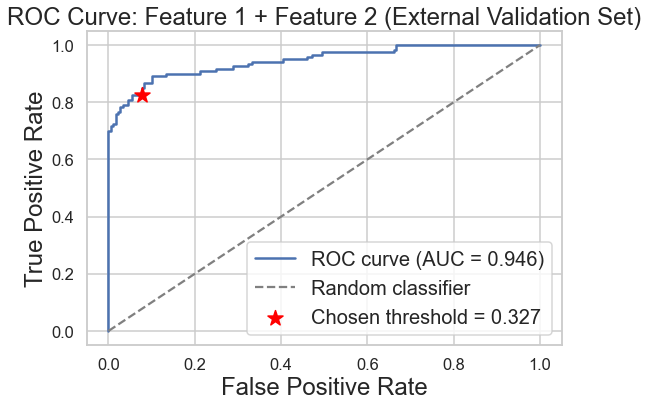


Accuracy:    88.3%
Precision:   0.876
Recall:      0.825
Sensitivity: 0.825
Specificity: 0.922
 


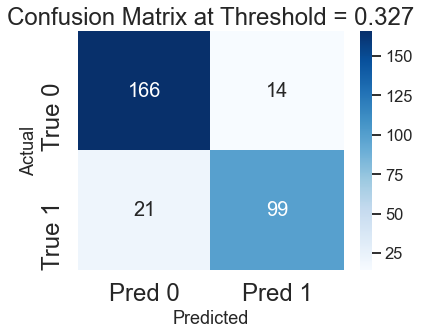

In [52]:
selected_features = ["Feature_1", "Feature_2"]
threshold = None  # set manually if you want, otherwise use Youden's J

# -----------------------------
# Data setup
# -----------------------------
X_subset = X_df[selected_features]

# -----------------------------
# Fit model on the full original dataset
# -----------------------------
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000),
)

model.fit(X_subset, y_series)

# Predict probabilities on the training data
train_probs = model.predict_proba(X_subset)[:, 1]

# ROC curve / AUC on the training data
auc_train = roc_auc_score(y_series, train_probs)
fpr, tpr, thresholds = roc_curve(y_series, train_probs)


# -----------------------------
# Print fitted model and coefficients
# -----------------------------
print("\nFitted model:")
print(model)

log_reg = model.named_steps["logisticregression"]
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": log_reg.coef_[0]
})

print("\nCoefficients:")
print(coef_df)
print("\nIntercept:", log_reg.intercept_[0])

print('')

# -----------------------------
# Threshold selection from training data
# -----------------------------
if threshold is None:
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)

    threshold = thresholds[best_idx]
    best_youden_j = youden_j[best_idx]
    best_sensitivity = tpr[best_idx]
    best_specificity = 1 - fpr[best_idx]

    print("Using Youden's J from training data to select threshold")
    print(f"Best threshold: {threshold:.3f}")
    print(f"Youden's J: {best_youden_j:.3f}")
    print(f"Sensitivity at threshold: {best_sensitivity:.3f}")
    print(f"Specificity at threshold: {best_specificity:.3f}")
else:
    print(f"Using user-specified threshold: {threshold:.3f}")
    
# -----------------------------
# Create a completely new external dataset
# -----------------------------
X_val, y_val = make_classification(
    n_samples=300,
    n_features=5,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    weights=[0.6, 0.4],
    hypercube=True,
    class_sep=1,
    shift=0.0,
    scale=1.0,
    shuffle=False,
    random_state=RANDOM_STATE + 1,
)

feature_names = [f"Feature_{i+1}" for i in range(X_val.shape[1])]
X_val_df = pd.DataFrame(X_val, columns=feature_names)
y_val_series = pd.Series(y_val, name="Class")

# Use the correct columns for prediction
X_val_subset = X_val_df[selected_features]

# Predict probabilities on external validation set
val_probs = model.predict_proba(X_val_subset)[:, 1]

# -----------------------------
# ROC curve / AUC on validation set
# -----------------------------
auc = roc_auc_score(y_val_series, val_probs)
fpr, tpr, thresholds = roc_curve(y_val_series, val_probs)

# Find the point on the validation ROC closest to the chosen threshold
threshold_idx = np.argmin(np.abs(thresholds - threshold))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})", linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.scatter(
    fpr[threshold_idx],
    tpr[threshold_idx],
    color="red",
    marker="*",
    s=250,
    label=f"Chosen threshold = {threshold:.3f}",
    zorder=5,
)
plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)
plt.title("ROC Curve: Feature 1 + Feature 2 (External Validation Set)", fontsize=24)
plt.legend(loc="lower right", fontsize=20)
plt.tight_layout()
plt.show()

# -----------------------------
# Classification metrics
# -----------------------------
y_pred = (val_probs >= threshold).astype(int)

cm = confusion_matrix(y_val_series, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision = precision_score(y_val_series, y_pred)
recall = recall_score(y_val_series, y_pred)
accuracy = accuracy_score(y_val_series, y_pred)
f1 = f1_score(y_val_series, y_pred)

# print("\nConfusion Matrix:")
# print(cm)

print(f"\nAccuracy:    {accuracy * 100:.1f}%")
print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
# print(f"F1 score:    {f1:.3f}")
print(' ')

# -----------------------------
# Confusion matrix plot
# -----------------------------
plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
    annot_kws={"size": 20},
)

ax.set_xlabel("Predicted", fontsize=18)
ax.set_ylabel("Actual", fontsize=18)
ax.set_title(f"Confusion Matrix at Threshold = {threshold:.3f}", fontsize=24)
ax.tick_params(axis='both', labelsize=24)

plt.tight_layout()
plt.show()

---

## Summary

In this tutorial example, we constructed and evaluated a binary classification pipeline for biological-style data using a synthetic dataset with known ground truth. The goal was to demonstrate how machine learning methods can recover informative signal from noisy predictors.

Key steps included:

- **Data generation:** We created a synthetic dataset with 1,000 samples and 5 features, where only two features contained true signal for class separation.
- **Exploratory feature analysis:** We compared feature distributions across classes using boxplots and nonparametric rank-sum tests to identify potential signal-bearing variables.
- **Modeling approach:** We trained a logistic regression classifier within a standardized scikit-learn pipeline.
- **Evaluation strategy:** Model performance was assessed using cross-validation and probabilistic metrics, emphasizing robustness rather than single train-test splits.
- **Model comparison framework:** The workflow is designed to support systematic comparison of feature subsets using statistical and predictive performance criteria (e.g., AIC/BIC and cross-validated metrics).

Overall, this example highlights how combining statistical testing, visualization, and regularized model evaluation provides a principled workflow for feature selection and classification in biological data settings.

## Discussion

**Exercises** — try changing one thing at a time and observe what happens:

1. Change `n_samples = 1000` to `n_samples = 500` or `n_samples = 100`. Does the best model match what we found before? How does this affect ROC AUC? 
2. Change `class_sep = 2` to `class_sep = 1`. This makes the classes less separable. How dpes this affect the ROC AUC?
3. Change `n_inform = 2` to `n_inform = 4`. Do the feature comparison plots change? Does the best model now use more features?
4. Change the class imbalance (e.g., `weights=[0.5, 0.5]`). How does this affect ROC AUC?
5. Remove feature standardization before fitting. Does performance change? Why?
6. What happens to AIC/BIC if you add the noise features to the best model?
